In [2]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.linear_model import LinearRegression

In [3]:
train_dataset = torchvision.datasets.MNIST(root="data/", train=True, download=True)
test_dataset = torchvision.datasets.MNIST(root="data/", train=False, download=True)

X_train = train_dataset.data.numpy().astype(np.float32).reshape(len(train_dataset), -1) / 255.0
Y_train = np.eye(10)[train_dataset.targets.numpy().astype(np.int32)]

X_test = test_dataset.data.numpy().astype(np.float32).reshape(len(test_dataset), -1) / 255.0
Y_test = np.eye(10)[test_dataset.targets.numpy().astype(np.int32)]

X = np.concatenate((X_train, X_test), axis=0)
Y = np.concatenate((Y_train, Y_test), axis=0)

print(X.shape)
print(Y.shape)

(70000, 784)
(70000, 10)


In [4]:
def ReLU(x):
    return np.maximum(0, x)

def Softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp = np.exp(x)
    return exp / np.sum(exp, axis=1, keepdims=True)

In [5]:
class Layer():
    def __init__(self, shape, activation=True):
        self.weights =  np.random.randn(*shape) * np.sqrt(2 / shape[0])
        self.biases = np.zeros((1,shape[1]))
        self.activation = activation
        
    def Forward(self, X):
        self.input = X
        self.z = np.dot(self.input, self.weights) + self.biases
        self.a = ReLU(self.z) if self.activation else self.z
        return self.a
    
    def Backward(self, gradOut, learningRate):
        da = (self.z > 0) if self.activation else 1
        dz = gradOut * da

        dw = np.dot(self.input.T, dz) / dz.shape[0]
        db = np.sum(dz, axis=0, keepdims=True) / dz.shape[0]

        self.weights -= dw * learningRate
        self.biases -= db * learningRate

        gradInput = np.dot(dz, self.weights.T)
        return gradInput

In [ ]:
class Network():
    def __init__(self, layerSizes = None):
        self.dims = layerSizes
        self.InitializeLayers(self.dims)

        self.learningRate = []
        self.epochs = []
        self.batchSize = []
        
        self.accuracyArray = []
        self.lossesArray = []

    @classmethod
    def FromFile(cls, filename = "models/best.npz"):
        model = cls()
        model.Load(filename)
        return model

    def InitializeLayers(self, layerSizes):
        self.layers = []
        if layerSizes is not None:
            for i in range(len(layerSizes)-1):
                self.layers.append(Layer((layerSizes[i], layerSizes[i+1]), i != len(layerSizes)-2))
            
    def Save(self, filename):
        model_data = {}

        model_data["dims"] = self.dims

        for i, layer in enumerate(self.layers):
            model_data[f"w{i}"] = layer.weights
            model_data[f"b{i}"] = layer.biases

            model_data["lr"] = np.array(self.learningRate, dtype=object)
            model_data["e"] = np.array(self.epochs, dtype=object)
            model_data["bs"] = np.array(self.batchSize, dtype=object)

            model_data["a"] = np.array(self.accuracyArray, dtype=object)
            model_data["l"] = np.array(self.lossesArray, dtype=object)

        np.savez(filename, **model_data)
        print(f"Model saved to {filename}")

    def Load(self, filename):
        model_data = np.load(f"{filename}.npz", allow_pickle=True)

        self.dims = model_data["dims"]
        self.InitializeLayers(self.dims)

        for i, layer in enumerate(self.layers):
            layer.weights = model_data[f"w{i}"]
            layer.biases = model_data[f"b{i}"]
            
        self.learningRate = model_data[f"lr"].tolist()
        self.epochs = model_data[f"e"].tolist()
        self.batchSize = model_data[f"bs"].tolist()
        
        self.accuracyArray = model_data["a"].tolist()
        self.lossesArray = model_data["l"].tolist() 

        print(f"Model loaded from \"{filename}\"")
    
    def Forward(self, X):
        for layer in self.layers:
            X = layer.Forward(X)
        return Softmax(X)
    
    def Predict(self, X):
        probs = self.Forward(X)
        return np.argmax(probs, axis=1)
    
    def Train(self, X, Y, X_test, Y_test, learningRate, epochs, batchSize):        
        self.learningRate.append(learningRate)
        self.epochs.append(epochs)
        self.batchSize.append(batchSize)
        
        losses = []
        accuracies = []
        n = len(X)
        for epoch in range(epochs):
            totalLoss = 0
            indices = np.random.permutation(n)
            for i in range(0, n, batchSize):
                batchIdx = indices[i:i+batchSize]
                x = X[batchIdx]
                y = Y[batchIdx]
                
                y_hat = self.Forward(x)
                grad = y_hat - y
                
                for layer in reversed(self.layers):
                    grad = layer.Backward(grad, learningRate)
                
                totalLoss += - np.sum(y * np.log(y_hat + 1e-12))
        
            loss = totalLoss / n
            preds = np.argmax(self.Forward(X_test), axis=1)
            true = np.argmax(Y_test, axis=1)
            accuracy = np.mean(preds == true)

            losses.append(loss)
            accuracies.append(accuracy)
            
            if (epoch+1) % 1 == 0:
                print(f"Epoch {epoch+1}: Loss={loss:.4f}  Test Accuracy={accuracy*100:.2f}%")
            
        self.accuracyArray.append(accuracies)
        self.lossesArray.append(losses)

    def PlotLossAccuracy(self, splitters : bool = True, linearFit : bool = True):
        losses = np.concatenate(self.lossesArray)
        accuracy = np.concatenate(self.accuracyArray)

        fig, ax = plt.subplots(1, 2, figsize=(12,6))

        midPercent = 0.8

        if splitters:
            offset = 0
            for i, run in enumerate(self.lossesArray):
                ax[0].axvline(offset, color='grey', linestyle='--') if i > 0 else None
                offset += len(run)

        ax[0].plot(losses, color='red', linestyle='-', label='Model Loss')
        ax[0].set_xlabel("Epoch")
        ax[0].set_ylabel("Average Loss")
        ax[0].legend()


        ax[1].plot(accuracy, color='green', linestyle='-', label='Model Accuracy')

        if splitters:
            offset = 0
            for i, run in enumerate(self.lossesArray):
                ax[1].axvline(offset, color='grey', linestyle='--') if i > 0 else None
                offset += len(run)

        if linearFit:
            offset = 0
            for i, run in enumerate(self.accuracyArray):
                run = np.array(run)
                run_len = len(run)
            
                start_local = int(run_len * midPercent)
                x_fit = np.arange(offset + start_local, offset + run_len).reshape(-1,1)
                y_fit = run[start_local:]
                
                fit = LinearRegression().fit(x_fit, y_fit)
                
                x_full = np.arange(offset, offset + run_len).reshape(-1,1)
                y_pred_full = fit.predict(x_full)
                
                ax[1].plot(x_full, y_pred_full, color='black', linestyle='--', label=f'Fit {i+1} ({fit.coef_[0]*10000:.2f}% per 100 epochs)')

                offset += run_len

        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Percentage Accuracy")
        ax[1].legend()

        plt.tight_layout()
        plt.show()

In [7]:
model = Network((784, 128, 128, 10))

In [ ]:
#loop_count = 0
#while True:
    #loop_count += 1
    #print(f"\n=== Training loop {loop_count} ===")
    
model.Train(X_train, Y_train, X_test, Y_test, 0.001, 5, 128)
    
    #model.Save("models/test")

Epoch 1: Loss=2.1637  Test Accuracy=43.25%
Epoch 2: Loss=1.8091  Test Accuracy=66.35%
Epoch 3: Loss=1.4616  Test Accuracy=75.07%
Epoch 4: Loss=1.1643  Test Accuracy=79.26%
Epoch 5: Loss=0.9502  Test Accuracy=81.62%


In [ ]:
model.Save(f"models/test")
print(f"Maximum accuracy reached by the model on most recent training loop: {np.max(model.accuracyArray[-1])}")
print(f"Minimum loss reached by the model on most recent training loop: {np.min(model.lossesArray[-1])}")
print("On the same iteration") if np.argmax(model.accuracyArray[-1])==np.argmin(model.lossesArray[-1]) else print("On different uterations")

Model saved to models/model2
Maximum accuracy reached by the model on most recent training loop: 0.9714
Minimum loss reached by the model on most recent training loop: 0.08104659237548158
On different uterations


Model loaded from "models/model2"


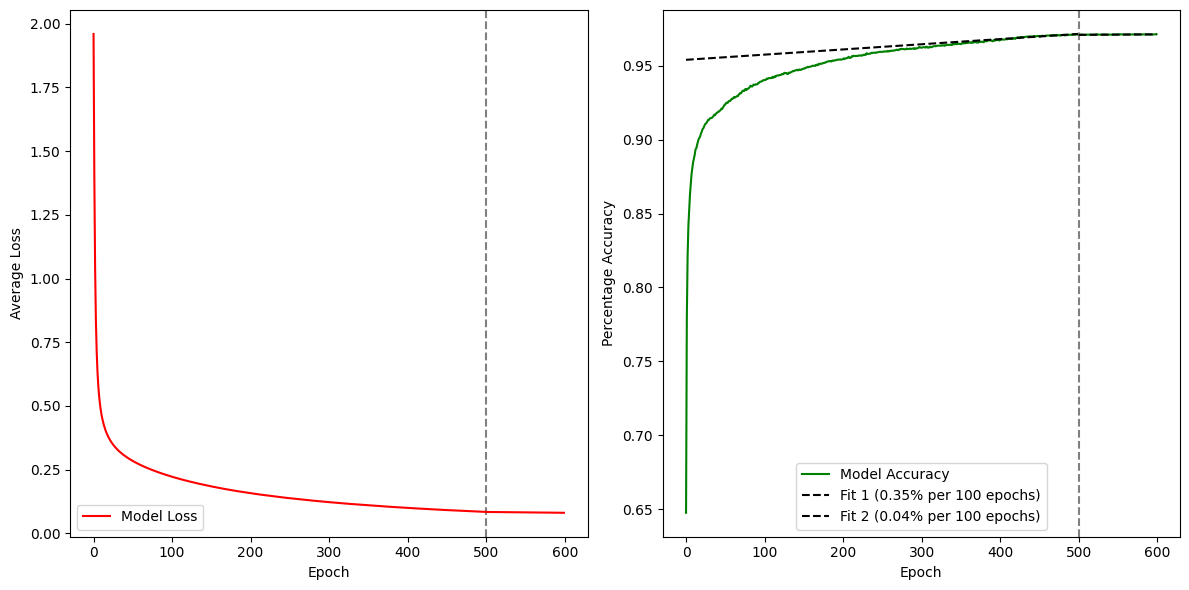

In [31]:
testModel = Network().FromFile("models/model2")
testModel.PlotLossAccuracy(splitters=True, linearFit=True)

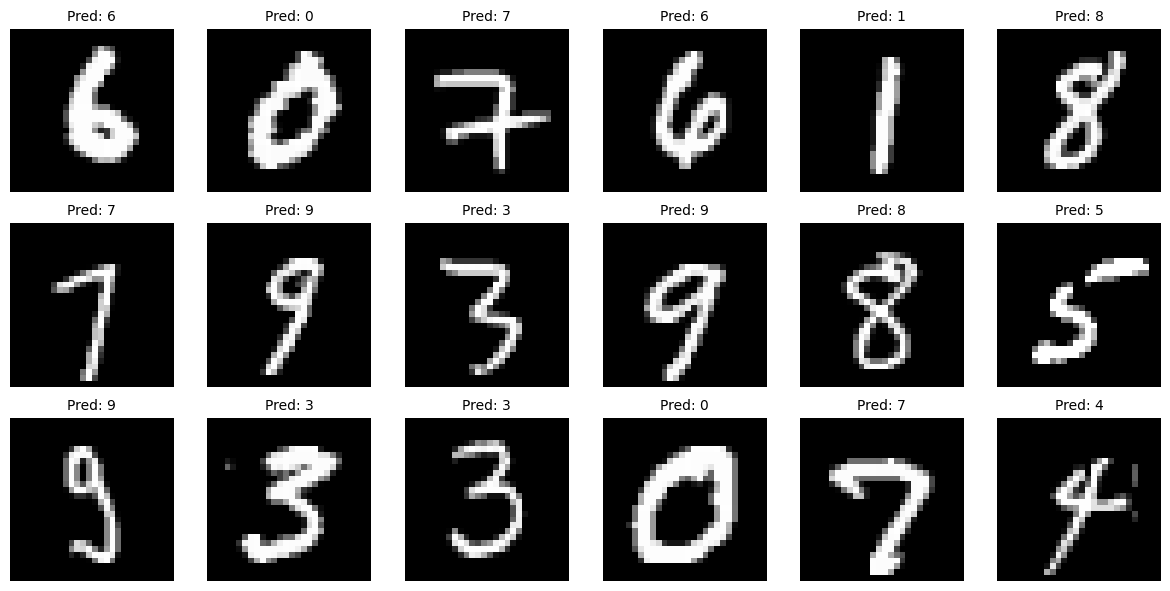

In [ ]:
offset = 2

fig, ax = plt.subplots(3, 6, figsize=(12,6))
for i in range(3):
    for j in range(6):
        idx = i*6 + j + offset*3*6
        img = train_dataset.data[idx].numpy()
        ax[i, j].imshow(img, cmap='gray')
        ax[i, j].axis('off')
        
        x = img.reshape(1, -1) / 255.0
        pred = model.predict(x)[0]
        ax[i, j].set_title(f"Pred: {pred}", fontsize=10)

plt.tight_layout()
plt.show()

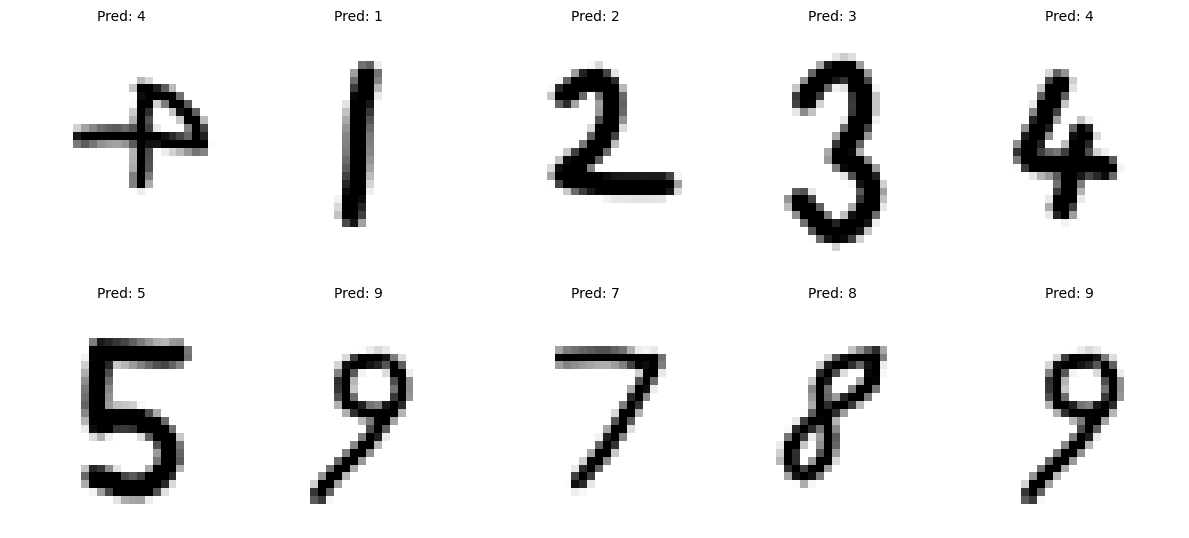

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(12,6))

for i in range(2):
    for j in range(5):
        idx = i*5 + j
        img = Image.open(f"testImages/{i*5+j}.png")
        ax[i, j].imshow(img, cmap='gray')
        ax[i, j].axis('off')
        
        x = 1-np.array(Image.open(f"testImages/{i*5+j}.png").convert("L")).reshape(1, 784) / 255.0
        pred = model.predict(x)[0]
        ax[i, j].set_title(f"Pred: {pred}", fontsize=10)

plt.tight_layout()
plt.show()